In [1]:
import sys
sys.path.append('..')
from fastai.vision.all import *
from mocatml.utils import *
convert_uuids_to_indices()
from mocatml.data import *
from mocatml.models.conv_rnn import *
from mocatml.models.transformer import *
from mocatml.models.phy_original import *
from mocatml.models.seq2seq import TeacherForcing
from mygrad import sliding_window_view
from tsai.imports import my_setup
from tsai.utils import yaml2dict, dict2attrdict
from fastai.callback.schedule import valley, steep
from fastai.callback.wandb import WandbCallback
import wandb

In [2]:
if torch.cuda.is_available():
    torch.cuda.set_device(0)
    print(torch.cuda.get_device_name())

Tesla V100-PCIE-32GB


In [3]:
from fastai.callback.schedule import LRFinder

@patch_to(LRFinder)
def after_fit(self):
    self.learn.opt.zero_grad() # Needed before detaching the optimizer for future fits
    tmp_f = self.path/self.model_dir/self.tmp_p/'_tmp.pth'
    if tmp_f.exists():
        self.learn.load(f'{self.tmp_p}/_tmp', with_opt=True, device='cpu')
        self.tmp_d.cleanup()

In [4]:
my_setup()

os              : Linux-5.10.209-llgrid-x86_64-with-glibc2.35
python          : 3.11.4
tsai            : 0.3.8
fastai          : 2.7.12
fastcore        : 1.5.29
torch           : 2.0.1+cu117
device          : 1 gpu (['Tesla V100-PCIE-32GB'])
cpu cores       : 40
threads per cpu : 2
RAM             : 377.57 GB
GPU memory      : [32.0] GB


In [5]:
config_base = yaml2dict('./config/base.yaml', attrdict=True)
config_base.phdnet = yaml2dict('./config/phdnet/phydnet.yaml', attrdict=True)
#config = AttrDict({**config_base, **config_e2e})
config = AttrDict(config_base)
config

```json
{ 'bs': 32,
  'data': { 'dataset': ['x2x2', 'x5x5', 'x10x10', 'x15x15'],
            'path': '~/mocat-ml/data/TLE_density_all_',
            'usage': [0.25, 0.5, 0.75, 1]},
  'device': 'cuda',
  'gap': 0,
  'horizon': 4,
  'lookback': 4,
  'lr_max': None,
  'mmap': True,
  'n_epoch': 20,
  'normalize': True,
  'num_workers': 0,
  'partial_loss': None,
  'phdnet': { 'attn': False,
              'blur': False,
              'coord_conv': False,
              'debug': False,
              'ks': 3,
              'n_in': 1,
              'n_out': 1,
              'norm': None,
              'rnn_ks': 5,
              'strategy': 'zero',
              'szs': [16, 64, 96]},
  'save_learner': True,
  'seed': None,
  'sel_steps': None,
  'stride': 8,
  'tmp_folder': 'tmp',
  'wandb': { 'dir': None,
             'enabled': True,
             'group': None,
             'log_learner': False,
             'mode': 'offline',
             'project': 'mocatml'}}
```

In [6]:
run = wandb.init(dir=ifnone(config.wandb.dir, '../'),
                 project=config.wandb.project, 
                 config=config,
                 group=config.wandb.group,
                 mode=config.wandb.mode, 
                 anonymous='never') if config.wandb.enabled else None
config = dict2attrdict(run.config) if config.wandb.enabled else config
config

```json
{ 'bs': 32,
  'data': { 'dataset': ['x2x2', 'x5x5', 'x10x10', 'x15x15'],
            'path': '~/mocat-ml/data/TLE_density_all_',
            'usage': [0.25, 0.5, 0.75, 1]},
  'device': 'cuda',
  'gap': 0,
  'horizon': 4,
  'lookback': 4,
  'lr_max': None,
  'mmap': True,
  'n_epoch': 20,
  'normalize': True,
  'num_workers': 0,
  'partial_loss': None,
  'phdnet': { 'attn': False,
              'blur': False,
              'coord_conv': False,
              'debug': False,
              'ks': 3,
              'n_in': 1,
              'n_out': 1,
              'norm': None,
              'rnn_ks': 5,
              'strategy': 'zero',
              'szs': [16, 64, 96]},
  'save_learner': True,
  'seed': None,
  'sel_steps': None,
  'stride': 8,
  'tmp_folder': 'tmp',
  'wandb': { 'dir': None,
             'enabled': True,
             'group': None,
             'log_learner': False,
             'mode': 'offline',
             'project': 'mocatml'}}
```

In [7]:
data = np.load(Path(config.data.path + config.data.dataset[0] + '.npy').expanduser(), 
               mmap_mode='c' if config.mmap else None)

data = data[:, :config.sel_steps]

data_sw = np.lib.stride_tricks.sliding_window_view(data, 
                                               config.lookback + config.horizon + config.gap, 
                                               axis=1)[:,::config.stride,:]
samples_per_simulation = data_sw.shape[1]
data_sw = data_sw.transpose(0,1,4,2,3)
data_sw = data_sw.reshape(-1, *data_sw.shape[2:])
data_sw = data_sw[:, :, :32, :32]
data_sw.shape

(30400, 8, 32, 32)

In [8]:
splits = RandomSplitter()(data)
ds = DensityData(data_sw, lbk=config.lookback, h=config.horizon, gap=config.gap)
train_idxs = calculate_sample_idxs(splits[0], samples_per_simulation)
valid_idxs = calculate_sample_idxs(splits[1], samples_per_simulation)

mocat_stats = (np.mean(data[splits[0]]), np.std(data[splits[0]]))

train_tl = TfmdLists(train_idxs, DensityTupleTransform(ds))
valid_tl = TfmdLists(valid_idxs, DensityTupleTransform(ds))
dls = DataLoaders.from_dsets(train_tl, valid_tl, bs=config.bs, device=default_device(),
                    after_batch=[Normalize.from_stats(*mocat_stats)] if \
                    config.normalize else None,
                    num_workers=config.num_workers)

In [9]:
if config.partial_loss is not None:
    loss_func = PartialStackLoss(config.partial_loss, loss_func=MSELossFlat())
    full_loss = StackLoss()
    full_loss.__name__ = "full_loss"
    metrics = [full_loss] # [StackLoss()]
else:
    loss_func = StackLoss(MSELossFlat())
    metrics = []
    
loss_func = StackLoss(MSELossFlat())
metrics = []

SuggestedLRs(valley=0.0003311311302240938)

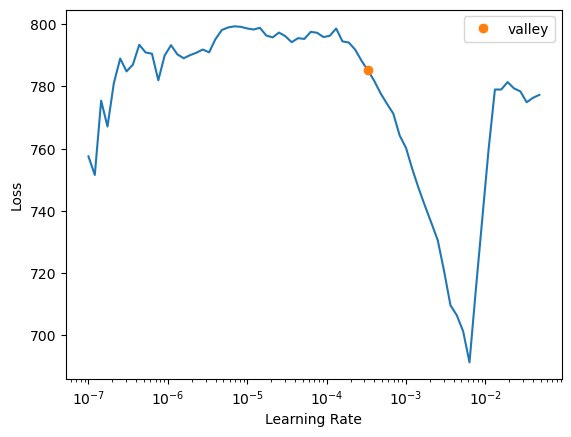

In [10]:
model = StackUnstack(TransformerTS(n_in=1, n_out=1))
cbs = L() + [ShowGraphCallback()]
learn = Learner(dls, model, loss_func=loss_func, metrics=metrics, splitter=partial(tf_split, stacked=True), cbs=cbs).to_fp16()
lr_max = learn.lr_find()
lr_max

epoch,train_loss,valid_loss,time
0,198.002975,142.178223,01:09
1,64.098053,61.890697,01:02
2,56.726982,55.661678,01:26
3,53.660927,56.535500,01:25
4,53.398014,54.030609,01:19
5,50.901211,54.147121,01:28
6,49.013020,53.223415,01:25
7,46.323528,52.592842,01:31
8,44.096809,51.822174,01:23
9,41.731556,53.943035,01:17


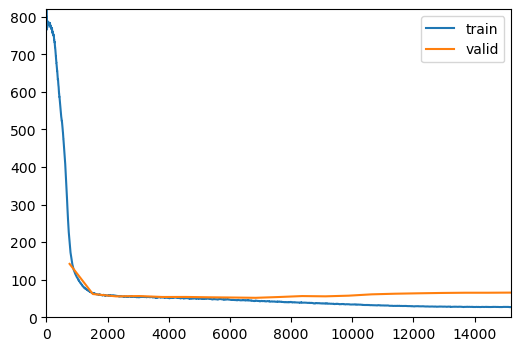

In [11]:
learn.fit_one_cycle(config.n_epoch, 1e-4)

SuggestedLRs(valley=0.0003311311302240938)

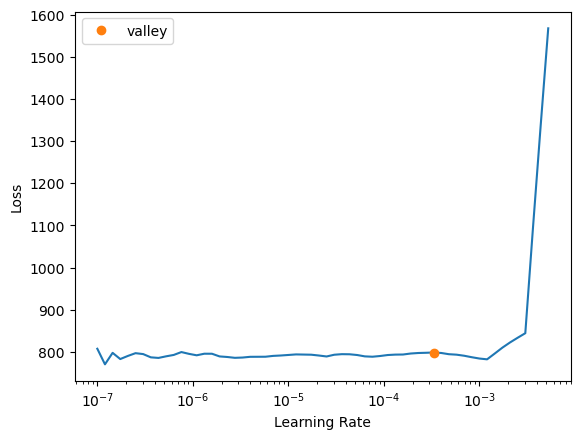

In [12]:
model = StackUnstack(TransformerTS(n_in=1, n_out=1))
cbs = L() + [ShowGraphCallback(), GradientClip]
learn = Learner(dls, model, loss_func=loss_func, metrics=metrics, splitter=partial(tf_split, stacked=True), cbs=cbs).to_fp16()
lr_max = learn.lr_find()
lr_max

epoch,train_loss,valid_loss,time
0,84.954338,78.100372,01:31
1,62.375832,59.921383,01:32
2,64.995964,95.346352,01:22
3,63.602016,57.708584,01:23
4,57.060036,106.625404,01:33
5,54.339775,60.906807,01:27
6,54.355999,54.768139,01:34
7,51.651554,58.923000,01:22
8,48.200691,52.841164,01:04
9,45.372524,54.045410,01:00


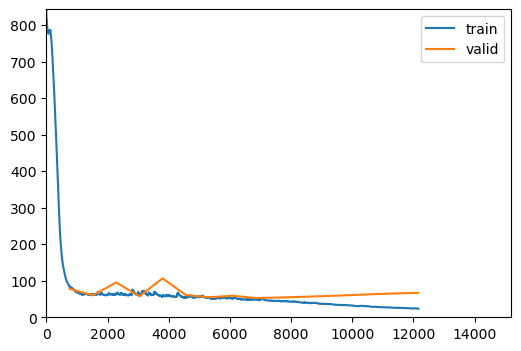

In [ ]:
learn.fit_one_cycle(config.n_epoch, lr_max = lr_max)

In [ ]:
model = StackUnstack(TransformerTS(n_in=1, n_out=1))
cbs = L() + [ShowGraphCallback()]
learn = Learner(dls, model, loss_func=loss_func, metrics=metrics, splitter=partial(tf_split, stacked=True), cbs=cbs).to_fp16()
lr_max = learn.lr_find()
lr_max

In [ ]:
learn.fit_one_cycle(40, 1e-5)